# 00 · Setup & Data Collection
**Dengue Outbreak Forecasting for Bangladesh — CSE 4113**

**What this notebook handles.** Collect daily dengue **cases** (base GitHub
series **+ our late-September 2026 extension** in `data/raw/`) and daily Dhaka
**weather** (NASA POWER), aggregate both to **complete 7-day weeks only**
(partial edge weeks dropped), merge, and save the single source of truth
`data/processed/dengue_weekly.csv`.

Run this **first** — notebooks 01–06 read what it writes.

### Step 1 — Mount Drive (Colab) and set the shared folder

In [1]:
# On Colab, run once to get XGBoost (used in 04-05):
!pip -q install xgboost

import os, numpy as np, pandas as pd

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/dengue-bd'          # keep identical in every notebook
    ON_COLAB = True
except Exception:
    BASE = os.path.abspath('dengue-bd')                 # local fallback
    ON_COLAB = False

for sub in ['data/raw', 'data/processed', 'models']:
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)
print('On Colab :', ON_COLAB); print('BASE     :', BASE)

Mounted at /content/drive
On Colab : True
BASE     : /content/drive/MyDrive/dengue-bd


### Step 2 — Write the shared model library
`dengue_models.py` holds the from-scratch Linear Regression (Week 2) and Bayesian classifier (Weeks 5–6) so notebooks 03–06 import the **same** classes.

In [2]:
MODELS_SRC = r'''"""Shared, from-scratch models for the dengue project.

Importing these from one module (instead of redefining them in each notebook)
means a model saved with joblib in 05 can be loaded in 06 without surprises.
"""
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin


class GDLinearRegressor(BaseEstimator, RegressorMixin):
    """Linear regression trained by batch gradient descent (Week 2).

    Expects already-scaled inputs (use a StandardScaler in front). Stores the
    mean-squared-error at every epoch in ``loss_`` so you can plot convergence.
    """

    def __init__(self, lr=0.05, epochs=3000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape
        self.w_ = np.zeros(d)
        self.b_ = 0.0
        self.loss_ = []
        for _ in range(self.epochs):
            pred = X @ self.w_ + self.b_
            err = pred - y                      # derivative of MSE
            self.w_ -= self.lr * (X.T @ err) / n
            self.b_ -= self.lr * err.mean()
            self.loss_.append(float(np.mean(err ** 2)))
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_


class GaussianBayesClassifier(BaseEstimator, ClassifierMixin):
    """Minimum-error-rate Bayes classifier, one full multivariate normal per
    class, parameters by maximum likelihood (Weeks 5-6).
    """

    def __init__(self, ridge=1e-6):
        self.ridge = ridge

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.means_, self.covs_, self.log_priors_ = {}, {}, {}
        n = len(y)
        for c in self.classes_:
            Xc = X[y == c]
            self.means_[c] = Xc.mean(axis=0)
            cov = np.cov(Xc, rowvar=False)
            cov = np.atleast_2d(cov) + self.ridge * np.eye(X.shape[1])
            self.covs_[c] = cov
            self.log_priors_[c] = np.log(len(Xc) / n)
        return self

    def _log_post(self, X, c):
        d = X - self.means_[c]
        inv = np.linalg.inv(self.covs_[c])
        _, logdet = np.linalg.slogdet(self.covs_[c])
        maha = np.einsum("ij,jk,ik->i", d, inv, d)
        return -0.5 * (maha + logdet) + self.log_priors_[c]

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        scores = np.column_stack([self._log_post(X, c) for c in self.classes_])
        return self.classes_[scores.argmax(axis=1)]
'''
with open(f'{BASE}/dengue_models.py', 'w') as f:
    f.write(MODELS_SRC)
import sys; sys.path.insert(0, BASE)
print('Wrote dengue_models.py')

Wrote dengue_models.py


### Step 3 — Data sources & helpers
`CASES_SOURCE`:
- **`'github'` (default)** — base daily DGHS series (≈ Jan 2024 → early Sep 2026),
  auto-downloaded, **plus** any local extension CSVs you place in `data/raw/`.
- **`'kaggle'`** — your uploaded `bd_dengue_daily.csv` (2019–2023) instead of GitHub.
- **`'synthetic'`** — offline sample (no internet).

**To include the late-September 2026 data:** put `dengue_daily_2026_sep.csv`
(columns `date`, `daily_admitted`) into `data/raw/`. It is appended automatically
and overrides overlapping base dates. Weather is always NASA POWER for Dhaka.

The helpers below aggregate **daily → weekly keeping only full 7-day weeks**, so
every row is a clean weekly aggregate with aligned weather.

In [3]:
CASES_SOURCE = 'github'   # 'github' | 'kaggle' | 'synthetic'

GH = 'https://raw.githubusercontent.com/md-naim-molla/Dengue-Forecasting/main/data'
DHAKA = dict(lat=23.81, lon=90.41)

def read_daily_cases_file(path):
    """Read one daily cases CSV and standardise to columns [date, cases]."""
    d = pd.read_csv(path, parse_dates=['date'])
    if 'daily_admitted' in d.columns:          # GitHub / DGHS schema
        d = d.rename(columns={'daily_admitted': 'cases'})
    if 'cases' not in d.columns:
        raise ValueError(f'{path}: expected a daily case column (daily_admitted or cases)')
    return d[['date', 'cases']].dropna()

def collect_daily_cases(base, use_github=True):
    """Combine the base GitHub daily series with any local extension CSVs
    dropped into data/raw/ (e.g. the late-September 2026 file). Newest wins."""
    frames = []
    if use_github:
        frames.append(read_daily_cases_file(f'{GH}/dengue_ml_dataset.csv'))
    for fn in ['dengue_daily_2026_sep.csv', 'bd_dengue_daily.csv']:
        p = f'{base}/data/raw/{fn}'
        if os.path.exists(p):
            frames.append(read_daily_cases_file(p)); print('  + appended local file:', fn)
    if not frames:
        raise FileNotFoundError('no daily case sources found')
    daily = pd.concat(frames, ignore_index=True)
    daily = daily.drop_duplicates('date', keep='last').sort_values('date')   # extension overrides base
    return daily

def fetch_daily_weather_nasa(start, end):
    """Daily Dhaka weather from NASA POWER -> columns [date, rain, temp, humidity]."""
    import requests
    url = ('https://power.larc.nasa.gov/api/temporal/daily/point'
           '?parameters=PRECTOTCORR,T2M,RH2M&community=AG'
           f"&longitude={DHAKA['lon']}&latitude={DHAKA['lat']}"
           f'&start={start}&end={end}&format=JSON')
    raw = requests.get(url, timeout=60).json()['properties']['parameter']
    wx = pd.DataFrame(raw)
    wx.index = pd.to_datetime(wx.index, format='%Y%m%d')
    wx = wx.rename(columns={'PRECTOTCORR': 'rain', 'T2M': 'temp', 'RH2M': 'humidity'})
    wx = wx.replace(-999, np.nan)                # NASA POWER missing-value sentinel
    return wx.reset_index(names='date')[['date', 'rain', 'temp', 'humidity']]

def daily_to_weekly(daily_cases, daily_wx):
    """Aggregate daily cases + daily weather to weekly, keeping ONLY complete
    7-day weeks with full weather alignment (drops partial leading/trailing weeks)."""
    c = daily_cases.copy()
    c['week'] = c['date'].dt.to_period('W-MON').dt.start_time
    cw = c.groupby('week').agg(total_cases=('cases', 'sum'),
                               n_days=('cases', 'size')).reset_index()
    w = daily_wx.copy()
    w['week'] = w['date'].dt.to_period('W-MON').dt.start_time
    ww = w.groupby('week').agg(rain=('rain', 'sum'), temp=('temp', 'mean'),
                               humidity=('humidity', 'mean'),
                               wx_days=('rain', 'size')).reset_index()
    m = cw.merge(ww, on='week', how='inner')
    full = m[(m['n_days'] == 7) & (m['wx_days'] == 7)].copy()   # <-- partial-week cleanup
    print(f'  weeks: {len(m)} merged, dropped {len(m) - len(full)} partial-edge, kept {len(full)}')
    return (full[['week', 'total_cases', 'rain', 'temp', 'humidity']]
            .sort_values('week').reset_index(drop=True))

def make_synthetic_daily(start='2019-01-01', end='2024-12-31', seed=42):
    """Offline fallback: realistic DAILY Bangladesh dengue + Dhaka weather.
    Returns (daily_cases[date,cases], daily_weather[date,rain,temp,humidity])."""
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start, end, freq='D'); n = len(dates)
    doy = dates.dayofyear.to_numpy().astype(float); yr = dates.year.to_numpy()
    temp = 26 + 5.5*np.sin(2*np.pi*(doy-60)/365) + rng.normal(0, 1.0, n)
    humidity = 72 + 12*np.sin(2*np.pi*(doy-120)/365) + rng.normal(0, 4, n)
    monsoon = np.exp(-0.5*((doy-210)/40.0)**2)                 # ~late July peak
    rain = np.clip(monsoon*rng.normal(14, 6, n) + rng.normal(0.5, 1.0, n), 0, None)
    rlag = np.zeros(n)
    for k in range(42, 71):                                    # ~6-10 week delayed effect
        rlag += np.r_[np.zeros(k), rain[:-k]] if k < n else np.zeros(n)
    rlag /= 29.0
    amp = np.array([{2019:1.25,2020:.35,2021:.7,2022:1.,2023:2.4,2024:1.6}.get(y,1.) for y in yr])
    mean_daily = amp*(2 + 8*rlag*np.clip(temp-24,0,None)*np.clip(humidity-60,0,None)/25.0
                      + 6*np.clip(np.sin(2*np.pi*(doy-230)/365), 0, None))
    cases = rng.poisson(np.clip(mean_daily, 0.2, None)).astype(int)
    dc = pd.DataFrame({'date': dates, 'cases': cases})
    dw = pd.DataFrame({'date': dates, 'rain': rain.round(1),
                       'temp': temp.round(2), 'humidity': humidity.round(1)})
    return dc, dw


### Step 4 — Build the weekly dataset
Real path (cases + NASA POWER) with a synthetic fallback. Both go through the same `daily_to_weekly` cleanup, so the partial-week rule always applies.

In [4]:
try:
    if CASES_SOURCE == 'synthetic':
        raise RuntimeError('forced synthetic')
    daily_cases = collect_daily_cases(BASE, use_github=(CASES_SOURCE == 'github'))
    start = daily_cases['date'].min().strftime('%Y%m%d')
    end   = daily_cases['date'].max().strftime('%Y%m%d')
    daily_wx = fetch_daily_weather_nasa(start, end)
    df = daily_to_weekly(daily_cases, daily_wx)
    if len(df) < 30:
        raise RuntimeError('too few complete weeks after cleanup')
    SOURCE = f'REAL (DGHS via {CASES_SOURCE} + local extension if present + NASA POWER)'
except Exception as e:
    dc, dw = make_synthetic_daily()                     # offline fallback (daily -> same cleanup)
    df = daily_to_weekly(dc, dw)
    SOURCE = 'SYNTHETIC fallback'
    print('Real data unavailable ->', type(e).__name__, str(e)[:80], '| using synthetic sample')

df = df.sort_values('week').reset_index(drop=True)
print('\nData source :', SOURCE)
print('Weeks        :', len(df), '(', df.week.min().date(), '->', df.week.max().date(), ')')
print(df.tail().to_string(index=False))

  weeks: 141 merged, dropped 2 partial-edge, kept 139

Data source : REAL (DGHS via github + local extension if present + NASA POWER)
Weeks        : 139 ( 2024-01-02 -> 2026-08-25 )
      week  total_cases  rain      temp  humidity
2026-07-28         3040 80.42 28.314286 90.101429
2026-08-04         3387 99.72 28.091429 89.544286
2026-08-11         4777 64.02 28.392857 89.700000
2026-08-18         5075 82.08 28.794286 88.697143
2026-08-25         5923 51.25 28.752857 89.447143


### Step 5 — Save + quick preview

Saved 139 weekly rows -> /content/drive/MyDrive/dengue-bd/data/processed/dengue_weekly.csv


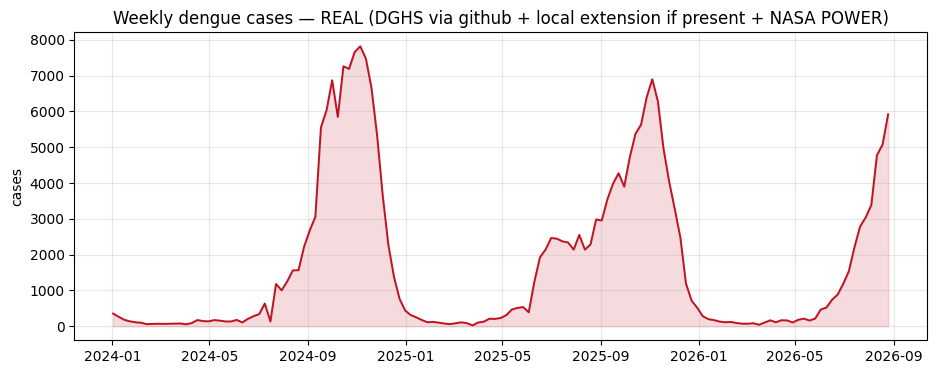

In [5]:
import matplotlib.pyplot as plt
path = f'{BASE}/data/processed/dengue_weekly.csv'
df.to_csv(path, index=False)
print('Saved', len(df), 'weekly rows ->', path)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df['week'], df['total_cases'], color='#c1121f', lw=1.4)
ax.fill_between(df['week'], df['total_cases'], color='#c1121f', alpha=0.15)
ax.set_title(f'Weekly dengue cases — {SOURCE}'); ax.set_ylabel('cases'); ax.grid(alpha=0.3); plt.show()

**Output:** `dengue_weekly.csv` (full weeks only). Next: **01 · EDA**.